# Google Maps Traffic — PNG Tile Approach

This notebook fetches **real-time traffic congestion** from **Google Maps traffic PNG tiles**
and assigns the congestion level directly to every edge in the duckOSM road network.

## How it differs from the Mapbox approach (notebook 3)

| Aspect | Mapbox (notebook 3) | Google PNG (this notebook) |
|---|---|---|
| Tile format | MVT binary (vector) | PNG raster image |
| Congestion encoding | property on each road segment | pixel **color** in the image |
| Contains geometry | Yes — LineString segments | No — only pixels |
| Extra step needed | Spatial map matching (notebook 4) | **None** — pixels sampled directly on OSM edges |

Because Google PNG tiles encode congestion as **color**, and we already have the OSM
edge geometry in DuckDB, we sample pixel colors **along each edge** and map them to
a congestion level — skipping the separate map-matching step entirely.

## Google Maps Traffic tile URL

```
https://maps.googleapis.com/maps/vt?lyrs=traffic&x={x}&y={y}&z={z}&key={API_KEY}
```

This returns a **256 × 256 RGBA PNG** with only the traffic overlay (no base map).
Transparent pixels mean no traffic data for that location.

## Color → congestion mapping

Google encodes congestion as road line colors in the PNG. We use the **HSV color space**
(Hue, Saturation, Value) which separates color (H) from brightness (V), making it more
robust than raw RGB comparisons:

| Pixel color | HSV range | Congestion |
|---|---|---|
| 🟢 Green | H 90–150°, S>40%, V>40% | `low` |
| 🟠 Orange/Yellow | H 20–60°, S>50%, V>60% | `moderate` |
| 🔴 Red | H 0–20° or 340–360°, S>60%, V>50% | `heavy` |
| ⬛ Dark red | H 0–20° or 340–360°, S>40%, V≤50% | `severe` |
| Transparent / gray | alpha<30 or S<15% or V<15% | no data |

## Pipeline

```
DuckDB (driving.edges)
        │
        ▼
Step 1 — Load OSM edge geometries
        │
        ▼
Step 2 — Find all tiles covering the boundary
        │
        ▼
Step 3 — Download Google traffic PNG tiles  (cached in tiles/google/)
        │
        ▼
Step 4 — Define color helpers
        │
        ▼
Step 5 — Sample pixel colors along each OSM edge → majority vote → congestion
        │
        ▼
Step 6 — Write congestion to DuckDB  (driving.edges + edge_congestion_history)
        │
        ▼
Step 7 — Visualize  →  Step 8 — Export CSV / GeoJSON
```

In [1]:
%pip install Pillow --quiet   # PIL for reading PNG tiles

Note: you may need to restart the kernel to use updated packages.


---
## Configuration

**No API key required.** This notebook uses Google's public tile CDN (`mt0.google.com`)
which serves map tiles without authentication — the same endpoint the Google Maps web
client uses. The tile URL combines a **roadmap layer** with the **traffic overlay**:

```
https://mt0.google.com/vt?lyrs=m@321,traffic|en&x={x}&y={y}&z={z}
```

- `m@321` — roadmap style, version 321 (light gray roads on white background)
- `traffic|en` — traffic overlay in English
- **Result:** a 256×256 RGB PNG showing roads colored by congestion level

**Color interpretation:** Green = low, Orange = moderate, Red = heavy, Dark red = severe.
Roads with no traffic data keep their default gray/white road color.

- `ZOOM` — tile zoom level. **14** is recommended.
- `N_SAMPLES` — sample points along each OSM edge. **8** is a good default.

In [ ]:
%%time
import os, colorsys, time, yaml
import numpy as np
import duckdb
import geopandas as gpd
import mercantile
import requests
import folium
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
from shapely.geometry import box
from shapely import get_coordinates
from shapely.geometry import LineString
from dotenv import load_dotenv

load_dotenv(Path('../.env'), override=True)

# ── Configuration ─────────────────────────────────────────────────────────
NAME      = 'sodermalm'
ZOOM      = 14       # tile zoom level (14 recommended)
N_SAMPLES = 8        # pixel sample points per OSM edge
TILES_DIR = Path('../tiles/google')   # PNG tile cache
OUTPUT_DIR = Path('../output')
# ─────────────────────────────────────────────────────────────────────────

# Read DuckDB path from config YAML
CONFIG_PATH = Path(f'../config/{NAME}.yaml')
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    DB_PATH       = Path(cfg['output_path']) / f"{cfg['name']}.duckdb"
    BOUNDARY_FILE = Path(cfg['boundary_path'])
else:
    DB_PATH       = Path(f'../db/{NAME}.duckdb')
    BOUNDARY_FILE = Path(f'../boundaries/{NAME}.geojson')
    print('WARNING: config not found — using default paths')

TILES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'DuckDB   : {DB_PATH}')
print(f'Boundary : {BOUNDARY_FILE}')
print(f'Zoom     : {ZOOM}   N_SAMPLES: {N_SAMPLES}')

---
## Step 1 — Load OSM edges from DuckDB

We read the `driving.edges` table that was built by notebook 2 (duckOSM).
The geometry column is stored as a DuckDB `GEOMETRY` type — we export it as WKT
and parse into shapely so we can compute sample points along each edge.

We keep only **line geometries** (LineString / MultiLineString) since the pixel
sampling requires a path to interpolate along.

In [3]:
%%time
con = duckdb.connect(str(DB_PATH), read_only=True)
con.execute('LOAD spatial')

df = con.execute("""
    SELECT edge_id, highway, name, length_m,
           ST_AsText(geometry) AS wkt_geom
    FROM driving.edges
""").df()
con.close()

edges = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df['wkt_geom']),
    crs='EPSG:4326',
).reset_index(drop=True)

# Keep only line geometries — point features can't be sampled along
edges = edges[edges.geometry.geom_type.isin(['LineString', 'MultiLineString'])]

print(f'Loaded {len(edges):,} line edges from {DB_PATH.name}')
print(f'Total network length: {edges["length_m"].sum()/1000:.1f} km')
print(f'Highway types: {sorted(edges["highway"].unique())}')

Loaded 4,554 line edges from sodermalm.duckdb
Total network length: 191.6 km
Highway types: ['living_street', 'primary', 'primary_link', 'residential', 'secondary', 'secondary_link', 'service', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link', 'unclassified']
CPU times: user 333 ms, sys: 35.3 ms, total: 368 ms
Wall time: 62.1 ms


---
## Step 2 — Find tiles covering the boundary

We use `mercantile` to enumerate all tiles at the chosen zoom level whose footprint
overlaps the boundary polygon. This is the same tile grid used for the Mapbox approach.

One PNG tile covers approximately **1 km × 1 km** at zoom 14 in Sweden.
Each tile is 256 × 256 pixels, so each pixel represents about **4 m × 4 m**.

In [4]:
%%time
gdf      = gpd.read_file(BOUNDARY_FILE).to_crs('EPSG:4326')
boundary = gdf.geometry.union_all()
w, s, e, n = boundary.bounds

tiles = [
    t for t in mercantile.tiles(w, s, e, n, zooms=ZOOM)
    if boundary.intersects(box(*mercantile.bounds(t)))
]

print(f'Boundary  : W={w:.4f} S={s:.4f} E={e:.4f} N={n:.4f}')
print(f'Tiles     : {len(tiles)} at zoom {ZOOM}')
print(f'Pixel res : ~{mercantile.bounds(tiles[0]).east - mercantile.bounds(tiles[0]).west:.4f}° per tile')

Boundary  : W=18.0261 S=59.3032 E=18.1072 N=59.3214
Tiles     : 8 at zoom 14
Pixel res : ~0.0220° per tile
CPU times: user 12.1 ms, sys: 4.67 ms, total: 16.8 ms
Wall time: 16.2 ms


---
## Step 3 — Download Google Maps traffic PNG tiles

### Tile URL format
```
https://maps.googleapis.com/maps/vt?lyrs=traffic&x={x}&y={y}&z={z}&key={API_KEY}
```
- `lyrs=traffic` requests the **traffic-only overlay** (no base map), returning a
  transparent PNG where only traffic-colored pixels are non-transparent.
- Tiles are downloaded in parallel (6 workers) and cached in `tiles/google/`.
  Re-running this cell with cached tiles is instant.

### What the tile contains
The PNG is RGBA (Red, Green, Blue, Alpha). Pixels with `alpha < 30` are fully
transparent — these locations have no traffic data. Traffic-colored pixels have
high alpha and one of the four congestion colors.

In [ ]:
%%time
# Google Maps CDN — no API key required for tile access
# lyrs=m,traffic  →  roadmap (light background) + traffic overlay
# This endpoint is Google's public tile CDN used by the web client.
GOOGLE_TILE_URL = 'https://mt0.google.com/vt'
TILE_PARAMS     = 'm@321,traffic|en'   # roadmap version 321 + traffic layer in English
MIN_TILE_SIZE   = 64                   # pixels — anything smaller is a placeholder/error


def download_google_tile(tile, out_dir, retries=3):
    """Download one Google Maps roadmap+traffic PNG tile. Returns (tile, Path) or (tile, None).

    Uses the public Google CDN (mt0.google.com) which does not require an API key.
    Files are cached — already-downloaded valid tiles are returned immediately.
    Tiles smaller than MIN_TILE_SIZE are treated as invalid and deleted.
    """
    path = out_dir / f'{tile.z}_{tile.x}_{tile.y}.png'

    # Validate any cached tile before reusing it
    if path.exists():
        try:
            img = Image.open(path)
            if img.size[0] < MIN_TILE_SIZE:
                path.unlink()
                print(f'  Deleted invalid cached tile {path.name} (size {img.size})')
            else:
                return tile, path
        except Exception:
            path.unlink(missing_ok=True)

    params  = {'lyrs': TILE_PARAMS, 'x': tile.x, 'y': tile.y, 'z': tile.z}
    headers = {'User-Agent': 'Mozilla/5.0'}  # required by Google CDN

    for attempt in range(retries):
        try:
            r = requests.get(GOOGLE_TILE_URL, params=params,
                             headers=headers, timeout=(5, 20))
        except requests.exceptions.Timeout:
            time.sleep(2 ** attempt)
            continue
        if r.status_code == 200:
            path.write_bytes(r.content)
            try:
                img = Image.open(path)
                if img.size[0] < MIN_TILE_SIZE:
                    path.unlink()
                    print(f'  {tile}: received tiny tile {img.size} — skipping')
                    return tile, None
            except Exception as e:
                path.unlink(missing_ok=True)
                return tile, None
            return tile, path
        if r.status_code == 429:
            time.sleep(2 ** attempt)
        else:
            print(f'  {tile} HTTP {r.status_code}')
            return tile, None
    return tile, None


# Download all tiles in parallel
tile_paths = {}
failed     = []
with ThreadPoolExecutor(max_workers=6) as pool:
    futures = {pool.submit(download_google_tile, t, TILES_DIR): t for t in tiles}
    for f in as_completed(futures):
        tile, path = f.result()
        if path:
            tile_paths[tile] = path
        else:
            failed.append(tile)

print(f'Downloaded : {len(tile_paths)}/{len(tiles)} tiles')
if failed:
    print(f'Failed     : {len(failed)} tiles')

### Inspect a sample tile

Before running the full analysis, it is worth visualising one tile to verify that
the downloaded PNG actually contains traffic colors. A correct tile shows:
- Transparent background (checkerboard pattern when displayed)
- Colored lines along roads: green, orange, or red

Tile     : Tile(x=9013, y=4819, z=14)
Size     : (1, 1)  (width x height pixels)
Visible  : 0 / 1 pixels (0.0%) have traffic data


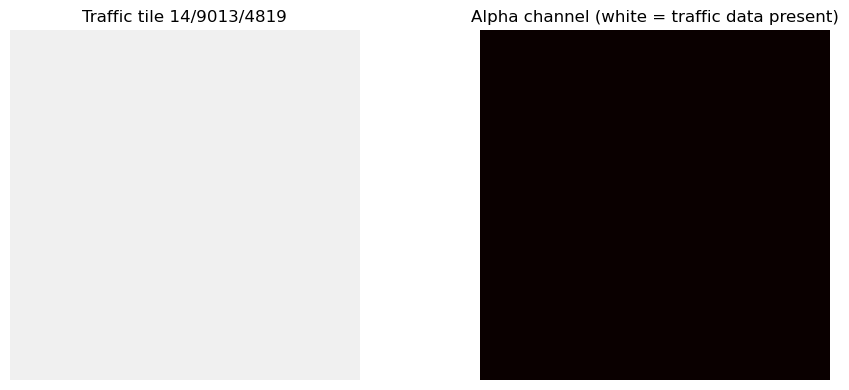

CPU times: user 91.3 ms, sys: 0 ns, total: 91.3 ms
Wall time: 91.2 ms


In [6]:
%%time
if tile_paths:
    sample_tile, sample_path = next(iter(tile_paths.items()))
    img = Image.open(sample_path).convert('RGBA')
    arr = np.array(img)

    # Count non-transparent pixels (alpha > 30) to confirm traffic data present
    visible = (arr[:, :, 3] > 30).sum()
    total   = arr.shape[0] * arr.shape[1]
    print(f'Tile     : {sample_tile}')
    print(f'Size     : {img.size}  (width x height pixels)')
    print(f'Visible  : {visible:,} / {total:,} pixels ({visible/total*100:.1f}%) have traffic data')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Show the tile (transparent = white background for display)
    bg = Image.new('RGB', img.size, (240, 240, 240))
    bg.paste(img, mask=img.split()[3])
    axes[0].imshow(bg)
    axes[0].set_title(f'Traffic tile {sample_tile.z}/{sample_tile.x}/{sample_tile.y}')
    axes[0].axis('off')
    # Show only the alpha channel to visualise coverage
    axes[1].imshow(arr[:, :, 3], cmap='hot')
    axes[1].set_title('Alpha channel (white = traffic data present)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

---
## Step 4 — Color classification helpers

### Why HSV instead of RGB?

RGB mixes color and brightness together, making thresholds brittle (e.g. a dark red
and a bright red look very different in RGB but both have Hue ≈ 0° in HSV).

**HSV** separates three independent axes:
- **H** (Hue 0–360°): the color itself — red=0°, yellow=60°, green=120°
- **S** (Saturation 0–1): how vivid — 0 = gray, 1 = pure color
- **V** (Value 0–1): brightness — 0 = black, 1 = bright

### `pixel_to_congestion(r, g, b, a)`
Classifies a single RGBA pixel into a congestion level.
Returns `None` for transparent or gray pixels (no traffic data).

### `sample_edge_congestion(geom, tile_imgs, zoom)`
Interpolates `N_SAMPLES` evenly-spaced points along an edge LineString,
samples the pixel color at each point, and returns the majority congestion
level. Severity is used as a tiebreaker (heavy beats moderate if tied).

In [ ]:
%%time

def pixel_to_congestion(r, g, b, a):
    """Map a single RGBA pixel to a congestion level string, or None.

    Uses HSV space — separates hue (color) from brightness (value),
    which is more robust than raw RGB thresholds.
    """
    if a < 200:                     # mostly transparent → no traffic data
        return None
    h, s, v = colorsys.rgb_to_hsv(r/255, g/255, b/255)
    h_deg = h * 360
    if s < 0.30 or v < 0.20:       # gray road or dark background — not a traffic color
        return None
    if 90 <= h_deg <= 150 and s > 0.35 and v > 0.35:   # green → low
        return 'low'
    if 20 <= h_deg < 90 and s > 0.45 and v > 0.55:     # yellow/orange → moderate
        return 'moderate'
    if (h_deg < 20 or h_deg > 340) and s > 0.50 and v > 0.40:   # red → heavy
        return 'heavy'
    if (h_deg < 20 or h_deg > 340) and s > 0.35 and v <= 0.40:  # dark red → severe
        return 'severe'
    return None


def sample_edge_congestion(geom, tile_imgs, zoom):
    """Determine congestion for an OSM edge by scanning all pixels along it.

    Traffic pixels are very sparse in the tile (only a few pixels wide on each road).
    Instead of sampling N random points, we:
      1. Densely interpolate positions along the edge (1 per ~2m)
      2. For each position, look at a 3×3 pixel neighborhood
      3. Return the most severe traffic color found

    This guarantees we don't miss a colored road pixel due to sparse sampling.
    """
    SEVERITY = {'severe': 4, 'heavy': 3, 'moderate': 2, 'low': 1}
    results  = []

    coords = get_coordinates(geom)
    if len(coords) < 2:
        return 'no data'

    line = LineString(coords)

    # Dense sampling: 1 point every ~2 metres along the edge
    # project to metres for length, then sample
    from shapely.ops import transform
    import pyproj
    proj = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True).transform
    line_m  = transform(proj, line)
    n_pts   = max(4, int(line_m.length / 2))   # at least 4, one per 2 m
    n_pts   = min(n_pts, 200)                   # cap to avoid very slow edges

    for d in np.linspace(0, 1, n_pts):
        pt  = line.interpolate(d, normalized=True)
        lon, lat = pt.x, pt.y

        tile = mercantile.tile(lon, lat, zoom)
        key  = (tile.x, tile.y, tile.z)
        if key not in tile_imgs:
            continue

        img    = tile_imgs[key]
        w, h   = img.size
        bounds = mercantile.bounds(tile)

        col = int((lon - bounds.west)  / (bounds.east  - bounds.west)  * w)
        row = int((bounds.north - lat) / (bounds.north - bounds.south) * h)

        # Check a 3×3 neighborhood around the exact pixel
        # Roads are only 1-3 pixels wide; the 3×3 window improves hit rate
        for dc in range(-1, 2):
            for dr in range(-1, 2):
                c = max(0, min(w - 1, col + dc))
                r = max(0, min(h - 1, row + dr))
                px = img.getpixel((c, r))
                cong = pixel_to_congestion(*px)
                if cong:
                    results.append(cong)

    if not results:
        return 'no data'
    return max(set(results), key=lambda c: SEVERITY.get(c, 0))


print('Helpers defined: pixel_to_congestion(), sample_edge_congestion()')

# Sanity check
tests = [
    ((80, 200, 60, 255), 'low'),
    ((255, 160, 30, 255), 'moderate'),
    ((220, 40, 20, 255), 'heavy'),
    ((120, 20, 20, 255), 'severe'),
    ((200, 200, 200, 255), None),
    ((0, 0, 0, 0), None),
]
print('\nColor classifier check:')
for (r, g, b, a), expected in tests:
    got = pixel_to_congestion(r, g, b, a)
    status = '✓' if got == expected else '✗'
    print(f'  {status} RGB({r},{g},{b}) a={a}  →  {got}  (expected {expected})')

---
## Step 5 — Sample pixel colors along every OSM edge

This is the core step that replaces the geometric map-matching used in the Mapbox
approach. Instead of matching Mapbox segment geometries to OSM edges, we use the
OSM edge geometry itself as a sampling path through the traffic tile pixels.

**Why this works:** Both the OSM edges and the Google traffic tiles are referenced
in the same coordinate system (WGS-84 / Web Mercator tile grid), so converting
an OSM edge coordinate to a pixel position in the tile is straightforward.

**Performance note:** Loading all PNG tiles into memory first (as RGBA PIL Images)
means each `getpixel()` call is O(1) — no disk I/O during the sampling loop.

In [ ]:
%%time
# Load all valid PNG tiles into memory (skip tiny invalid placeholder tiles)
tile_imgs = {}
for tile, path in tile_paths.items():
    try:
        img = Image.open(path).convert('RGBA')
        if img.size[0] < MIN_TILE_SIZE:
            print(f'  Skipping {path.name}: too small {img.size} — re-run the download cell')
            continue
        tile_imgs[(tile.x, tile.y, tile.z)] = img
    except Exception as e:
        print(f'  Could not load {path.name}: {e}')

print(f'Loaded {len(tile_imgs)} valid PNG tiles ({list(tile_imgs.values())[0].size if tile_imgs else "—"})')

if not tile_imgs:
    raise RuntimeError(
        "No valid tiles loaded.\n"
        "Re-run the download cell — cached 1×1 placeholder tiles may still exist."
    )

# Scan each OSM edge — dense sampling (1 pt per ~2m) + 3×3 neighborhood
# Traffic pixels are sparse (~1 per 1000 pixels) so we must be thorough
edge_congestion = {}
no_data_count   = 0

for _, row in edges.iterrows():
    cong = sample_edge_congestion(row.geometry, tile_imgs, ZOOM)
    if cong != 'no data':
        edge_congestion[int(row['edge_id'])] = cong
    else:
        no_data_count += 1

edges['congestion'] = edges['edge_id'].map(edge_congestion).fillna('no data')

matched_pct = len(edge_congestion) / max(len(edges), 1) * 100
print(f'\nEdges with congestion : {len(edge_congestion):,} / {len(edges):,}  ({matched_pct:.1f}%)')
print(f'Edges with no data    : {no_data_count:,}')
print('\nCongestion distribution:')
print(edges['congestion'].value_counts().to_string())

---
## Step 6 — Write congestion to DuckDB

Two writes happen here:

1. **Latest snapshot** — `driving.edges.congestion` is updated with the current values.
   This is what routing tools and queries will read.

2. **History** — one row per edge is appended to `edge_congestion_history` with the
   current `run_id` and timestamp. This keeps a time-series record that can be queried
   to see how congestion changed between Google fetches over time.

The `runs` table also gets a new row recording the metadata of this fetch
(source: `google`, timestamp, tile count, edge count).

In [9]:
%%time
import pandas as pd
from datetime import datetime, timezone

fetched_at = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

con = duckdb.connect(str(DB_PATH))
con.execute('LOAD spatial')

# ── runs table — log this fetch execution ─────────────────────────────────
con.execute("""
    CREATE TABLE IF NOT EXISTS runs (
        run_id        INTEGER PRIMARY KEY,
        boundary_name VARCHAR,
        zoom          INTEGER,
        fetched_at    TIMESTAMP,
        n_tiles       INTEGER,
        n_segments    INTEGER
    )
""")
run_id = con.execute("SELECT coalesce(max(run_id), 0) + 1 FROM runs").fetchone()[0]
con.execute("INSERT INTO runs VALUES (?, ?, ?, ?, ?, ?)",
            [run_id, f'{NAME}_google', ZOOM, fetched_at,
             len(tile_paths), len(edge_congestion)])

# ── driving.edges.congestion — update latest snapshot ─────────────────────
con.execute("ALTER TABLE driving.edges ADD COLUMN IF NOT EXISTS congestion VARCHAR DEFAULT 'no data'")
con.executemany("UPDATE driving.edges SET congestion = ? WHERE edge_id = ?",
                [(cong, eid) for eid, cong in edge_congestion.items()])

# ── edge_congestion_history — append time-series record ───────────────────
con.execute("""
    CREATE TABLE IF NOT EXISTS edge_congestion_history (
        run_id     INTEGER,
        edge_id    INTEGER,
        congestion VARCHAR,
        matched_at TIMESTAMP
    )
""")
con.executemany("INSERT INTO edge_congestion_history VALUES (?, ?, ?, ?)",
                [(run_id, int(eid), cong, fetched_at)
                 for eid, cong in edge_congestion.items()])

total_history = con.execute("SELECT count(*) FROM edge_congestion_history").fetchone()[0]
total_runs    = con.execute("SELECT count(*) FROM runs").fetchone()[0]
con.close()

print(f'Run ID           : {run_id}  (source: Google Maps PNG)')
print(f'Edges updated    : {len(edge_congestion):,}')
print(f'History total    : {total_history:,} rows across {total_runs} run(s)')
print(f'Fetched at       : {fetched_at} UTC')

InvalidInputException: Invalid Input Error: executemany requires a non-empty list of parameter sets to be provided

---
## Step 7 — Visualize

The folium map shows every OSM edge colored by the congestion level sampled from
Google Maps. Open Google Maps in another tab and enable the traffic layer on the
same area to compare visually.

| Color | Congestion | Meaning |
|---|---|---|
| 🟢 Green | `low` | Free flow — sampled green pixels |
| 🟠 Orange | `moderate` | Reduced speed — sampled orange/yellow pixels |
| 🔴 Red | `heavy` | Significant slowdown — sampled red pixels |
| ⬛ Dark red | `severe` | Near standstill — sampled dark red pixels |
| ⬜ Gray | `no data` | Tile not available or no traffic pixels on this edge |

In [10]:
%%time
COLORS = {'low':'#00c800','moderate':'#ffa500','heavy':'#ff4500','severe':'#8b0000','no data':'#cccccc'}

lines  = edges[edges.geometry.geom_type.isin(['LineString','MultiLineString'])]
bds    = lines.total_bounds
center = [(bds[1]+bds[3])/2, (bds[0]+bds[2])/2]

m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')
folium.GeoJson(
    gdf.__geo_interface__,
    style_function=lambda _: {'color':'navy','weight':2,'fillOpacity':0.05},
    tooltip=None, popup=None,
).add_to(m)
folium.GeoJson(
    lines.__geo_interface__,
    style_function=lambda feat: {
        'color':  COLORS.get(feat['properties'].get('congestion','no data'),'#cccccc'),
        'weight': 3 if feat['properties'].get('congestion','no data') != 'no data' else 1.5,
    },
    tooltip=None, popup=None,
).add_to(m)
m

CPU times: user 121 ms, sys: 0 ns, total: 121 ms
Wall time: 120 ms


---
## Step 8 — Export CSV and GeoJSON

Save the enriched edges as files alongside the Mapbox outputs so they can be
compared or used in QGIS / kepler.gl.

The `_google` suffix in the filename distinguishes these from Mapbox outputs.

In [11]:
%%time
from shapely import get_coordinates as gc

geojson_out = OUTPUT_DIR / f'{NAME}_edges_traffic_google.geojson'
csv_out     = OUTPUT_DIR / f'{NAME}_edges_traffic_google.csv'

edges.to_file(geojson_out, driver='GeoJSON')
print(f'Saved GeoJSON → {geojson_out}  ({len(edges):,} edges)')

csv_df = edges.drop(columns=['geometry','wkt_geom'], errors='ignore').copy()
edges_m = edges.to_crs('EPSG:3857')
centroids        = edges_m.geometry.centroid.to_crs('EPSG:4326')
csv_df['lon']    = centroids.x.round(6)
csv_df['lat']    = centroids.y.round(6)
csv_df['length_m'] = edges_m.geometry.length.round(1)
all_coords           = edges.geometry.apply(gc)
csv_df['start_lon']  = all_coords.apply(lambda c: round(c[ 0][0], 6))
csv_df['start_lat']  = all_coords.apply(lambda c: round(c[ 0][1], 6))
csv_df['end_lon']    = all_coords.apply(lambda c: round(c[-1][0], 6))
csv_df['end_lat']    = all_coords.apply(lambda c: round(c[-1][1], 6))
csv_df.to_csv(csv_out, index=False)
print(f'Saved CSV     → {csv_out}')

print(f'\nFinal congestion distribution:')
print(edges['congestion'].value_counts().to_string())

Saved GeoJSON → ../output/sodermalm_edges_traffic_google.geojson  (4,554 edges)
Saved CSV     → ../output/sodermalm_edges_traffic_google.csv

Final congestion distribution:


KeyError: 'congestion'